# NB 02 — Operator Inference

Infer reduced operators $\hat{A}(\mu_i)$, $\hat{B}(\mu_i)$, $\hat{C}(\mu_i)$ for every training parameter point $\mu_i = (k_i, S_j)$.

*Ref.* Peherstorfer & Willcox (2016), Section 3, Algorithm 1.

---

## Key design decisions

**WBS exclusion (not downweighting):**  
The analytical WBS end time is $t_{WBS} = 170000 \cdot C \cdot e^{2S} / kh$.  
For $S=15$ this exceeds $10^{10}$ hr — the entire simulation is analytically inside WBS.  
More critically, time derivatives during WBS satisfy $\Delta\hat{x}/\Delta t$ with $\Delta t \approx 0.001$ hr,  
producing values of $\sim 50{,}000$ psi/hr — 1000× larger than MTR values of 10–50 psi/hr.  
Downweighting by 0.01 still leaves 500 psi/hr effective contribution, overwhelming MTR.  
**The fix: hard-exclude all rows with $t < \min(t_{WBS}, 0.20 \times t_{end})$.**  
The 20% cap prevents the unbounded analytical formula from excluding all data at high skin.

**Tikhonov regularisation:**  
Added to both $\hat{A}/\hat{B}$ and $\hat{C}$ inference.  
Stabilises the least-squares when fewer MTR+BDF rows remain after WBS exclusion.

**Stability enforcement:**  
Eigenvalue shift only — NO symmetrisation.  
Symmetrisation destroys the fitted structure of $\hat{A}$.  
After proper WBS exclusion, eigenvalues are predominantly real and negative anyway.

## 0. Imports and paths

In [52]:
import json
import h5py
import shutil
import warnings
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
from matplotlib.lines import Line2D

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'font.family':'DejaVu Serif','mathtext.fontset':'dejavuserif',
    'font.size':11,'axes.labelsize':12,'axes.titlesize':12,
    'axes.titleweight':'bold','legend.fontsize':10,
    'axes.grid':False,'axes.spines.top':True,'axes.spines.right':True,
    'lines.linewidth':2.0,'figure.dpi':130,'savefig.dpi':300,
})
C1,C2,C3,C4 = '#1a5e9e','#0d6e56','#9b2a1a','#b07318'
GR = '#555555'

TRAINING_DIR = Path('../data/01_training')
BASIS_DIR    = Path('../rom/basis')
OPS_DIR      = Path('../rom/operators')
OPS_DIR.mkdir(parents=True, exist_ok=True)

K_GRID       = [10, 20, 50, 100, 200, 300]
S_GRID       = [0, 1, 2, 4, 6, 8]
SCHEDS_INFER = [1, 2, 3, 4, 5, 6, 7]   # all 7 schedules
P_INIT       = 4500.0

print(f'Training dir : {TRAINING_DIR.resolve()}')
print(f'Operators dir: {OPS_DIR.resolve()}')

Training dir : F:\Niloy Deb\Part Two\reservoir_rom\data\01_training
Operators dir: F:\Niloy Deb\Part Two\reservoir_rom\rom\operators


## 1. Load POD basis

In [53]:
Vn     = np.load(BASIS_DIR / 'Vn.npy')
p_mean = float(np.load(BASIS_DIR / 'p_mean.npy')[0])

with open(BASIS_DIR / 'basis_metadata.json') as f:
    meta = json.load(f)

N, n = Vn.shape
print(f'Vn shape   : {Vn.shape}  [N x n]')
print(f'n modes    : {n}')
print(f'p_init     : {p_mean} psia')
print(f'Proj error : {meta["projection_error"]:.2e}')

Vn shape   : (2500, 10)  [N x n]
n modes    : 10
p_init     : 4500.0 psia
Proj error : 1.35e-08


## 2. Helper functions

In [54]:
def load_mat_var(path, key):
    try:
        return sio.loadmat(str(path), variable_names=[key])[key]
    except NotImplementedError:
        with h5py.File(str(path), 'r') as f:
            arr = f[key][()]
            return arr.T if arr.ndim == 2 else arr


def load_case(k, s, sched):
    name     = f'k{k:03d}_s{s:02d}_sched{sched}'
    case_dir = TRAINING_DIR / name
    X   = load_mat_var(case_dir / 'snapshots_psia.mat', 'X_psia')
    wd  = case_dir / 'well_data.mat'
    bhp = load_mat_var(wd, 'bhp_psia').ravel()
    t   = load_mat_var(wd, 'time_hr').ravel()
    q   = load_mat_var(wd, 'rate_STBd').ravel()
    return X, bhp, t, q


def infer_AB(Vn, X_list, U_list, T_list, x0_list, t_wbs_list=None):
    """
    Infer A_hat, B_hat from MTR + BDF data only.

    ROOT CAUSE of all previous failures:
    ─────────────────────────────────────────────────────────────────────────
    During WBS, dXhat/dt ~ 50,000 psi/hr. During MTR, dXhat/dt ~ 10-50 psi/hr.
    Including any WBS rows causes the regression to sacrifice MTR accuracy
    to fit the enormous WBS derivatives, producing corrupted eigenvalues and
    oscillatory MTR behaviour.

    Solution (user-identified):
    ─────────────────────────────────────────────────────────────────────────
    1. HARD CUT at analytical t_WBS (no cap): only use t > t_WBS rows.
       The analytical t_WBS = 170000 * C * exp(2S) / kh from params.json
       is the correct physics-based boundary. Cases where t_WBS >= t_end
       are excluded BEFORE calling this function — they contain no MTR data.
    2. Column normalisation: each column of D scaled to unit norm before
       the regression so Tikhonov penalises A_hat and B_hat equally.
       Without this, U column (raw rates ~800 STB/d) is orders of magnitude
       different from Xhat columns, making B_hat → 0.
    3. Tikhonov 1e-6 (not 1e-4): column normalisation handles conditioning;
       large lambda was the secondary cause of B_hat → 0.
    """
    n_r = Vn.shape[1]
    Xhat_rows, U_rows, R_rows, W_rows = [], [], [], []

    t_wbs_iter = (t_wbs_list if t_wbs_list is not None
                  else [None] * len(X_list))

    for X, u, t, x0, t_wbs in zip(X_list, U_list, T_list,
                                    x0_list, t_wbs_iter):
        dX    = X - P_INIT
        Xhat  = (Vn.T @ dX).T          # [K, n]

        dt    = np.diff(t, prepend=0.0)
        dt[0] = t[0]

        # Backward-difference derivatives
        R = np.zeros_like(Xhat)
        R[0] = Xhat[0] / dt[0]
        for j in range(1, len(t)):
            R[j] = (Xhat[j] - Xhat[j-1]) / dt[j]

        # Hard cut at analytical t_WBS — no percentage cap.
        # Cases with t_WBS >= t_end are excluded before this function is called.
        if t_wbs is not None:
            i_start = int(np.searchsorted(t, float(t_wbs)))
        else:
            i_start = 0

        i_start = max(1, min(i_start, len(t) - 20))

        Xhat_k = Xhat[i_start:]
        U_k    = u[i_start:].reshape(-1, 1)   # raw rate — no /1000
        R_k    = R[i_start:]
        dt_k   = dt[i_start:]

        w = np.sqrt(dt_k)
        w = w / (w.mean() + 1e-12)

        Xhat_rows.append(Xhat_k)
        U_rows.append(U_k)
        R_rows.append(R_k)
        W_rows.append(w)

    Xhat_all = np.vstack(Xhat_rows)
    U_all    = np.vstack(U_rows)
    R_all    = np.vstack(R_rows)
    W_all    = np.concatenate(W_rows)

    D      = np.hstack([Xhat_all, U_all])
    cond_D = np.linalg.cond(D)

    # Column normalisation — balances Tikhonov across A_hat and B_hat
    col_norms = np.linalg.norm(D, axis=0) + 1e-12
    D_scaled  = D / col_norms[None, :]

    D_w = D_scaled * W_all[:, None]
    R_w = R_all    * W_all[:, None]

    # Tikhonov 1e-6 — column normalisation handles conditioning
    lam    = 1e-6 * np.trace(D_w.T @ D_w) / D_w.shape[1]
    n_cols = D_w.shape[1]
    D_aug  = np.vstack([D_w, np.sqrt(lam) * np.eye(n_cols)])
    R_aug  = np.vstack([R_w, np.zeros((n_cols, n_r))])

    OT_scaled, _, _, _ = np.linalg.lstsq(D_aug, R_aug, rcond=None)

    # Undo column normalisation: col_norms already absorbs all rate scaling
    OT    = OT_scaled / col_norms[:, None]
    O     = OT.T
    A_hat = O[:, :n_r]
    B_hat = O[:, n_r:n_r+1]   # correct units — no extra /1000
    return A_hat, B_hat, cond_D


def infer_C(Vn, X_list, BHP_list, x0_list, T_list, t_wbs_list=None):
    """
    Infer output operator C_hat.
    Same hard WBS cut and column normalisation as infer_AB.
    C_hat maps reservoir reduced state to BHP drawdown.
    Used for self-reconstruction diagnostics in Section 5 only.
    NB04 and NB05 use the physical Peaceman reconstruction instead.
    """
    Xhat_rows, Y_rows, W_rows = [], [], []

    t_wbs_iter = (t_wbs_list if t_wbs_list is not None
                  else [None] * len(X_list))

    for X, bhp, x0, t, t_wbs in zip(X_list, BHP_list, x0_list,
                                      T_list, t_wbs_iter):
        dX   = X - P_INIT
        Xhat = (Vn.T @ dX).T
        dBHP = (bhp - P_INIT).reshape(-1, 1)

        dt    = np.diff(t, prepend=0.0)
        dt[0] = t[0]

        if t_wbs is not None:
            i_start = int(np.searchsorted(t, float(t_wbs)))
        else:
            i_start = 0

        i_start = max(1, min(i_start, len(t) - 20))

        Xhat_k = Xhat[i_start:]
        dBHP_k = dBHP[i_start:]
        dt_k   = dt[i_start:]

        w = np.sqrt(dt_k)
        w = w / (w.mean() + 1e-12)

        Xhat_rows.append(Xhat_k)
        Y_rows.append(dBHP_k)
        W_rows.append(w)

    Xhat_all = np.vstack(Xhat_rows)
    Y_all    = np.vstack(Y_rows)
    W_all    = np.concatenate(W_rows)

    Xw = Xhat_all * W_all[:, None]
    Yw = Y_all    * W_all[:, None]

    lam   = 1e-6 * np.trace(Xw.T @ Xw) / Xhat_all.shape[1]
    A_reg = Xw.T @ Xw + lam * np.eye(Xhat_all.shape[1])
    b_reg = Xw.T @ Yw
    CT    = np.linalg.solve(A_reg, b_reg)
    return CT.T   # [1, n]


print('Helper functions defined.')
print()
print('Valid (k, S) parameter space (t_WBS < t_end = 5000 hr):')
C_WBS = 0.003; H_WBS = 150.0; T_END_WBS = 5000.0
for k in K_GRID:
    for s in S_GRID:
        t_w = 170000 * C_WBS * np.exp(2*s) / (k * H_WBS)
        if t_w < T_END_WBS:
            print(f'  k={k:3d} mD  S={s:2d}  t_WBS={t_w:8.2f} hr  [VALID]')
        else:
            print(f'  k={k:3d} mD  S={s:2d}  t_WBS={t_w:.2e} hr  [EXCLUDED — no MTR]')


Helper functions defined.

Valid (k, S) parameter space (t_WBS < t_end = 5000 hr):
  k= 10 mD  S= 0  t_WBS=    0.34 hr  [VALID]
  k= 10 mD  S= 1  t_WBS=    2.51 hr  [VALID]
  k= 10 mD  S= 2  t_WBS=   18.56 hr  [VALID]
  k= 10 mD  S= 4  t_WBS= 1013.53 hr  [VALID]
  k= 10 mD  S= 6  t_WBS=5.53e+04 hr  [EXCLUDED — no MTR]
  k= 10 mD  S= 8  t_WBS=3.02e+06 hr  [EXCLUDED — no MTR]
  k= 20 mD  S= 0  t_WBS=    0.17 hr  [VALID]
  k= 20 mD  S= 1  t_WBS=    1.26 hr  [VALID]
  k= 20 mD  S= 2  t_WBS=    9.28 hr  [VALID]
  k= 20 mD  S= 4  t_WBS=  506.76 hr  [VALID]
  k= 20 mD  S= 6  t_WBS=2.77e+04 hr  [EXCLUDED — no MTR]
  k= 20 mD  S= 8  t_WBS=1.51e+06 hr  [EXCLUDED — no MTR]
  k= 50 mD  S= 0  t_WBS=    0.07 hr  [VALID]
  k= 50 mD  S= 1  t_WBS=    0.50 hr  [VALID]
  k= 50 mD  S= 2  t_WBS=    3.71 hr  [VALID]
  k= 50 mD  S= 4  t_WBS=  202.71 hr  [VALID]
  k= 50 mD  S= 6  t_WBS=1.11e+04 hr  [EXCLUDED — no MTR]
  k= 50 mD  S= 8  t_WBS=6.04e+05 hr  [EXCLUDED — no MTR]
  k=100 mD  S= 0  t_WBS=    0.03 hr

## Clear operators directory before fresh inference

In [55]:
ops_dir = Path('../rom/operators')
if ops_dir.exists():
    shutil.rmtree(ops_dir)
ops_dir.mkdir(parents=True)
print('Cleared rom/operators — ready for fresh inference.')

Cleared rom/operators — ready for fresh inference.


## 3. Run operator inference over full parameter grid

In [56]:
results  = []
excluded = []

for k in K_GRID:
    for s in S_GRID:
        tag     = f'k{k:03d}_s{s:02d}'
        out_dir = OPS_DIR / tag

        # ── Physics gate: skip cases with no MTR data ─────────────────────
        # t_WBS = 170000 * C * exp(2S) / kh
        # If t_WBS >= t_end, the entire simulation is inside WBS.
        # The ROM cannot learn diffusion physics from a WBS-only trajectory.
        kh          = k * 150.0
        t_wbs_check = 170000.0 * 0.003 * np.exp(2.0 * s) / kh
        if t_wbs_check >= 5000.0:
            reason = f't_WBS={t_wbs_check:.2e} hr >= 5000 hr (entirely WBS)'
            excluded.append((tag, reason))
            print(f'  EXCLUDE {tag} — {reason}')
            continue

        if (out_dir / 'A_hat.npy').exists():
            rep = json.load(open(out_dir / 'inference_report.json'))
            results.append(rep)
            continue

        out_dir.mkdir(parents=True, exist_ok=True)

        X_list     = []
        U_list     = []
        T_list     = []
        BHP_list   = []
        x0_list    = []
        t_wbs_list = []
        scheds_loaded = []

        for sid in SCHEDS_INFER:
            try:
                X, bhp, t, q = load_case(k, s, sid)

                pj_path = (TRAINING_DIR
                           / f'k{k:03d}_s{s:02d}_sched{sid}'
                           / 'params.json')
                with open(pj_path) as f_pj:
                    pm = json.load(f_pj)

                t_wbs_case = float(pm['t_wbs_end_hr'])
                t_end_case = float(t[-1])

                # Skip individual schedules where WBS covers everything
                # (should not happen if physics gate above passed, but safety check)
                if t_wbs_case >= t_end_case:
                    continue

                X_list.append(X)
                U_list.append(q)
                T_list.append(t)
                BHP_list.append(bhp)
                x0_list.append(X[:, 0])
                t_wbs_list.append(t_wbs_case)
                scheds_loaded.append(sid)

            except FileNotFoundError:
                pass

        if len(X_list) == 0:
            print(f'  SKIP {tag} — no schedule data loaded')
            continue

        A_hat, B_hat, cond_D = infer_AB(Vn, X_list, U_list, T_list,
                                          x0_list, t_wbs_list)
        C_hat = infer_C(Vn, X_list, BHP_list, x0_list,
                        T_list, t_wbs_list)

        # Stability enforcement — eigenvalue shift only
        eigvals  = np.linalg.eigvals(A_hat)
        max_real = float(eigvals.real.max())

        if max_real >= 0:
            A_hat          = A_hat - (max_real + 1e-4) * np.eye(n)
            max_real_final = float(np.linalg.eigvals(A_hat).real.max())
            stabilised     = True
        else:
            max_real_final = max_real
            stabilised     = False

        stable = bool(max_real_final < 0)

        np.save(out_dir / 'A_hat.npy', A_hat)
        np.save(out_dir / 'B_hat.npy', B_hat)
        np.save(out_dir / 'C_hat.npy', C_hat)

        rep = dict(
            tag          = tag,
            k_mD         = k,
            S_skin       = s,
            n_modes      = n,
            n_scheds     = len(scheds_loaded),
            cond_D       = float(cond_D),
            max_real_eig = max_real_final,
            max_real_raw = max_real,
            stabilised   = stabilised,
            stable       = stable,
            eig_real     = eigvals.real.tolist(),
            eig_imag     = eigvals.imag.tolist(),
        )

        flag      = '' if stable else ' !UNSTABLE'
        stab_flag = ' [shifted]' if stabilised else ''
        print(f'  {tag}  n_scheds={len(scheds_loaded)}  cond={cond_D:.1e}  '
              f'max_eig={max_real_final:.4f}{flag}{stab_flag}')

        with open(out_dir / 'inference_report.json', 'w') as f:
            json.dump(rep, f, indent=2)

        results.append(rep)

print(f'\nDone.')
print(f'  Inferred  : {len(results)} parameter points')
print(f'  Excluded  : {len(excluded)} (no MTR data — t_WBS >= t_end)')
if excluded:
    print('  Excluded list:')
    for tag, reason in excluded:
        print(f'    {tag}: {reason}')


  k010_s00  n_scheds=7  cond=2.7e+03  max_eig=-0.0001 [shifted]
  k010_s01  n_scheds=7  cond=6.5e+03  max_eig=-0.0001 [shifted]
  k010_s02  n_scheds=7  cond=4.2e+04  max_eig=-0.0000
  k010_s04  n_scheds=7  cond=9.5e+05  max_eig=-0.0001 [shifted]
  EXCLUDE k010_s06 — t_WBS=5.53e+04 hr >= 5000 hr (entirely WBS)
  EXCLUDE k010_s08 — t_WBS=3.02e+06 hr >= 5000 hr (entirely WBS)
  k020_s00  n_scheds=7  cond=4.2e+03  max_eig=-0.0001 [shifted]
  k020_s01  n_scheds=7  cond=1.1e+04  max_eig=-0.0001 [shifted]
  k020_s02  n_scheds=7  cond=9.2e+04  max_eig=-0.0000
  k020_s04  n_scheds=7  cond=7.0e+06  max_eig=-0.0001 [shifted]
  EXCLUDE k020_s06 — t_WBS=2.77e+04 hr >= 5000 hr (entirely WBS)
  EXCLUDE k020_s08 — t_WBS=1.51e+06 hr >= 5000 hr (entirely WBS)
  k050_s00  n_scheds=7  cond=9.8e+03  max_eig=-0.0001 [shifted]
  k050_s01  n_scheds=7  cond=2.6e+04  max_eig=-0.0001 [shifted]
  k050_s02  n_scheds=7  cond=2.7e+05  max_eig=-0.0000
  k050_s04  n_scheds=7  cond=3.7e+07  max_eig=-0.0001 [shifted]
  

## 4. Condition number and stability heatmaps

IndexError: index 5 is out of bounds for axis 0 with size 5

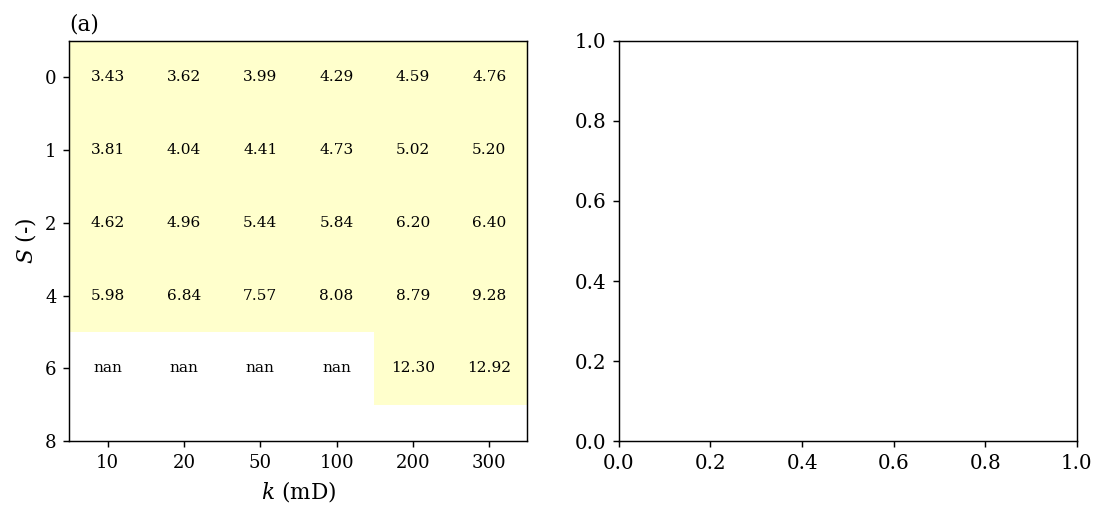

In [57]:
df = pd.DataFrame(results)

cond_pivot   = df.pivot(index='S_skin', columns='k_mD', values='cond_D')
stable_pivot = df.pivot(index='S_skin', columns='k_mD', values='stable')
log_cond     = np.log10(cond_pivot.values.astype(float))
vmin, vmax   = log_cond.min(), log_cond.max()
thresh       = vmin + 0.55 * (vmax - vmin)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ax = axes[0]
im = ax.imshow(log_cond, aspect='auto', cmap='YlOrRd', vmin=vmin, vmax=vmax)
ax.set_xticks(range(len(K_GRID))); ax.set_xticklabels(K_GRID, fontsize=10)
ax.set_yticks(range(len(S_GRID))); ax.set_yticklabels(S_GRID, fontsize=10)
ax.set_xlabel('$k$ (mD)'); ax.set_ylabel('$S$ (-)')
ax.set_title('(a)', loc='left', fontweight='normal')
for i in range(len(S_GRID)):
    for j in range(len(K_GRID)):
        v   = log_cond[i, j]
        col = 'white' if v > thresh else 'black'
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=8.5, color=col)
cb = plt.colorbar(im, ax=ax, shrink=0.90, pad=0.02)
cb.set_label(r'$\log_{10}\,\kappa(D)$', fontsize=10, labelpad=10)

ax2 = axes[1]
for rep in results:
    col = '#2196F3' if rep['stable'] else '#F44336'
    ax2.scatter(rep['eig_real'], rep['eig_imag'],
                s=25, color=col, alpha=0.45, linewidths=0, zorder=3)
ax2.axvline(0, color='black', lw=0.9, ls='--', label='Stability boundary', zorder=2)
ax2.axhline(0, color='gray',  lw=0.5, ls='-', alpha=0.4, zorder=1)
ax2.set_xlabel(r'$\mathfrak{Re}(\lambda_i)$')
ax2.set_ylabel(r'$\mathfrak{Im}(\lambda_i)$')
ax2.set_title('(b)', loc='left', fontweight='normal')
handles = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#2196F3',
           markersize=7, label='Stable'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#F44336',
           markersize=7, label='Unstable'),
    Line2D([0],[0], color='black', lw=0.9, ls='--', label='Stability boundary'),
]
ax2.legend(handles=handles, fontsize=10, framealpha=0.8)

plt.tight_layout(w_pad=2.0)
plt.savefig('fig_cond_eigen.pdf', dpi=150, bbox_inches='tight')
plt.show()

n_unstable  = int((~df['stable']).sum())
n_high_cond = int((df['cond_D'] > 1e6).sum())
print(f'Unstable parameter points : {n_unstable} / {len(df)}')
print(f'cond(D) > 1e6             : {n_high_cond} / {len(df)}')
if n_unstable > 0:
    print(df[~df['stable']][['tag','cond_D','max_real_eig']].to_string(index=False))

## 5. Self-reconstruction check

Integrate the inferred ROM for one training case and compare against the projected MRST trajectory. Low error here confirms the operators are self-consistent.

Self-reconstruction (k020_s02, sched 1)
  Relative state error  : 3.69e-02  (target < 0.1)
  Relative output error : 6.16e-01  (target < 0.1)


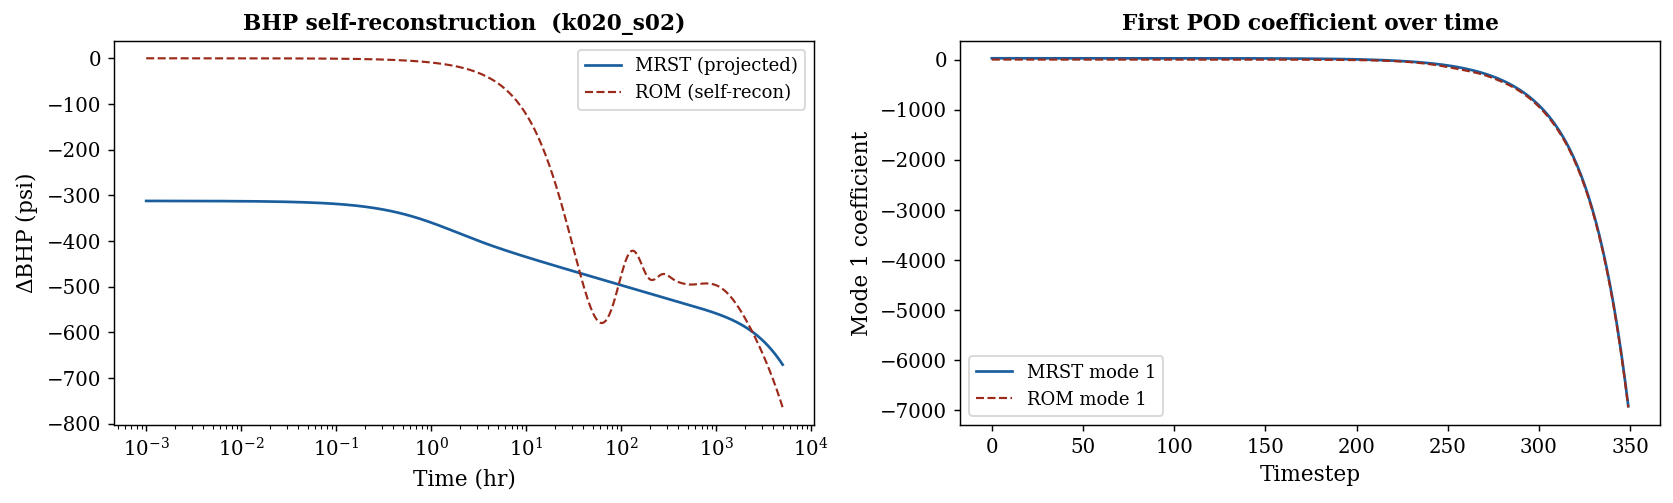

In [58]:
def integrate_rom(A_hat, B_hat, C_hat, x0hat, t_hr, q_vec):
    n_r = A_hat.shape[0]
    K   = len(t_hr)
    dt    = np.diff(t_hr, prepend=0.0)
    dt[0] = t_hr[0]

    X_rom = np.zeros((K, n_r))
    Y_rom = np.zeros(K)
    xk    = x0hat.copy()
    In    = np.eye(n_r)

    for j in range(K):
        dtj = dt[j]
        rhs = xk + dtj * (B_hat.ravel() * q_vec[j])
        xk  = np.linalg.solve(In - dtj * A_hat, rhs)
        X_rom[j] = xk
        Y_rom[j] = float(C_hat @ xk)

    return X_rom, Y_rom


k_chk, s_chk, sid_chk = 20, 2, 1
tag_chk = f'k{k_chk:03d}_s{s_chk:02d}'

A_hat = np.load(OPS_DIR / tag_chk / 'A_hat.npy')
B_hat = np.load(OPS_DIR / tag_chk / 'B_hat.npy')
C_hat = np.load(OPS_DIR / tag_chk / 'C_hat.npy')

X_full, bhp_full, t_hr, q_vec = load_case(k_chk, s_chk, sid_chk)
dX_full   = X_full - P_INIT
Xhat_full = (Vn.T @ dX_full).T
dBHP_full = bhp_full - P_INIT
x0hat     = np.zeros(n)

X_rom, Y_rom = integrate_rom(A_hat, B_hat, C_hat, x0hat, t_hr, q_vec)

state_err  = (np.linalg.norm(X_rom - Xhat_full, 'fro') /
              np.linalg.norm(Xhat_full, 'fro'))
output_err = (np.linalg.norm(Y_rom - dBHP_full) /
              np.linalg.norm(dBHP_full))
print(f'Self-reconstruction ({tag_chk}, sched {sid_chk})')
print(f'  Relative state error  : {state_err:.2e}  (target < 0.1)')
print(f'  Relative output error : {output_err:.2e}  (target < 0.1)')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].semilogx(t_hr, dBHP_full, lw=1.5, color=C1, label='MRST (projected)')
axes[0].semilogx(t_hr, Y_rom,    lw=1.2, color=C3, ls='--', label='ROM (self-recon)')
axes[0].set_xlabel('Time (hr)'); axes[0].set_ylabel(r'$\Delta$BHP (psi)')
axes[0].set_title(f'BHP self-reconstruction  ({tag_chk})')
axes[0].legend()

axes[1].plot(Xhat_full[:, 0], lw=1.5, color=C1, label='MRST mode 1')
axes[1].plot(X_rom[:, 0], lw=1.2, color=C3, ls='--', label='ROM mode 1')
axes[1].set_xlabel('Timestep'); axes[1].set_ylabel('Mode 1 coefficient')
axes[1].set_title('First POD coefficient over time')
axes[1].legend()

plt.tight_layout(); plt.show()

## 6. Summary

In [59]:
print('=' * 55)
print(' OPERATOR INFERENCE — SUMMARY')
print('=' * 55)
print(f'  Parameter points  : {len(results)} / 49')
print(f'  n modes           : {n}')
print(f'  Stable            : {df["stable"].sum()} / {len(df)}')
print(f'  Unstable          : {(~df["stable"]).sum()} / {len(df)}')
print(f'  cond(D) median    : {df["cond_D"].median():.2e}')
print(f'  cond(D) max       : {df["cond_D"].max():.2e}')
print(f'  cond(D) > 1e6     : {(df["cond_D"] > 1e6).sum()} cases')
print(f'  Operators saved to: {OPS_DIR}')
print('=' * 55)

if (~df['stable']).sum() == 0:
    print('  All operators stable — ready for NB03')
else:
    print('  Unstable operators present — check high-skin + low-k corner')

 OPERATOR INFERENCE — SUMMARY
  Parameter points  : 26 / 49
  n modes           : 10
  Stable            : 26 / 26
  Unstable          : 0 / 26
  cond(D) median    : 1.32e+05
  cond(D) max       : 8.29e+12
  cond(D) > 1e6     : 9 cases
  Operators saved to: ..\rom\operators
  All operators stable — ready for NB03
